## Imports and Reading Results

In [227]:
# install the package but not necessary
%env HTTP_PROXY=http://proxy:80
%env HTTPS_PROXY=http://proxy:80
%pip install -e .. 

env: HTTP_PROXY=http://proxy:80
env: HTTPS_PROXY=http://proxy:80
Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///home/hpc/iwi7/iwi7101h/i7-IDS
  Preparing metadata (setup.py) ... done
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached pluggy-1.6.0-py3-none-any.whl.metadata (4.8 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
Using cached pluggy-1.6.0-py3-none-any.whl (20 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/3 [tqdm]  WARNING: The script tqdm is installed in '/home/hpc/iwi7/iwi7101h/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Attempting uninstall: ids_expt━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [pluggy]
    Found existing installation: ids_expt 0.1━━━━━━━━━━━━━━━━━ 1/3 [pluggy]
    Uninstalling ids_expt-0.1:m━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [pluggy]
      Successfully uninstalled ids_expt-0.1╸━━━━━━━━

In [1]:
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set global font family and size
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif", "serif"]
mpl.rcParams["font.size"] = 12  # Adjust per Springer guidelines
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.titlesize"] = 13
mpl.rcParams["xtick.labelsize"] = 11
mpl.rcParams["ytick.labelsize"] = 11
mpl.rcParams["legend.fontsize"] = 11

# Optional: PDF/LaTeX text rendering for enhanced output
mpl.rcParams["text.usetex"] = False

In [2]:
adv_block_path = Path("../results/adversarial_blocking")
save_dir = Path("../results/adversarial_blocking")

In [3]:
models = list(adv_block_path.iterdir())
models

[WindowsPath('../results/adversarial_blocking/mobilenet_v3_large_normalized_nosampling'),
 WindowsPath('../results/adversarial_blocking/mobilenet_v3_large_nosampling'),
 WindowsPath('../results/adversarial_blocking/resnet18_normalized_nosampling'),
 WindowsPath('../results/adversarial_blocking/resnet18_nosampling')]

## Adversarial Images

<>:143: SyntaxWarning: invalid escape sequence '\e'
<>:143: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Viper\AppData\Local\Temp\ipykernel_17000\3073018264.py:143: SyntaxWarning: invalid escape sequence '\e'
  title = f"$\epsilon={title}$"


[0.001, 0.01, 0.1, 0.2, 0.3, 0.5]


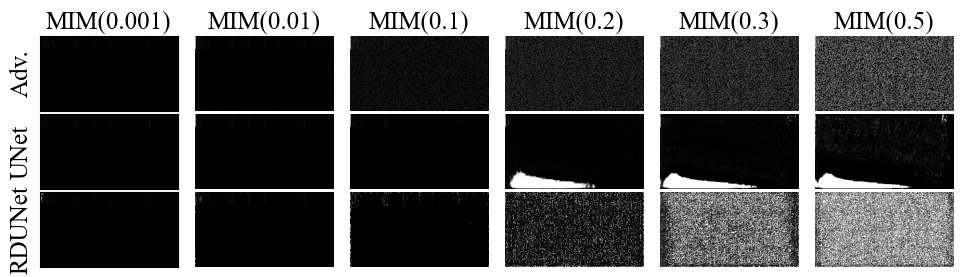

[0.001, 0.01, 0.1, 0.2, 0.3, 0.5]


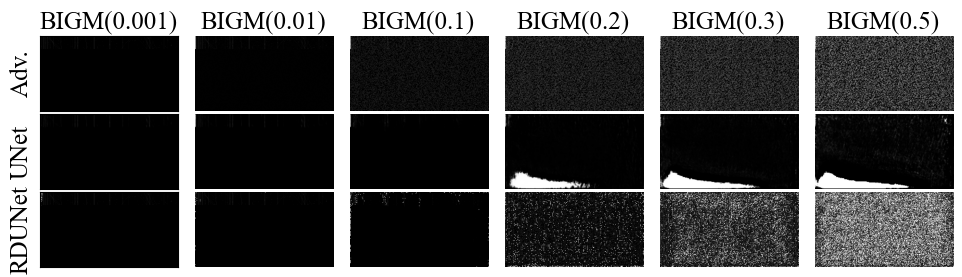

[0.001, 0.01, 0.1, 0.2, 0.3, 0.5]


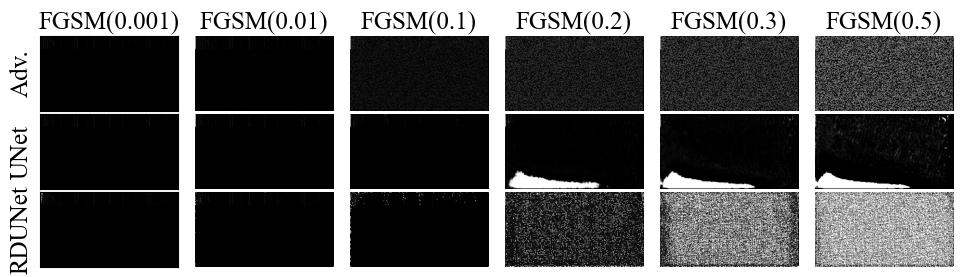

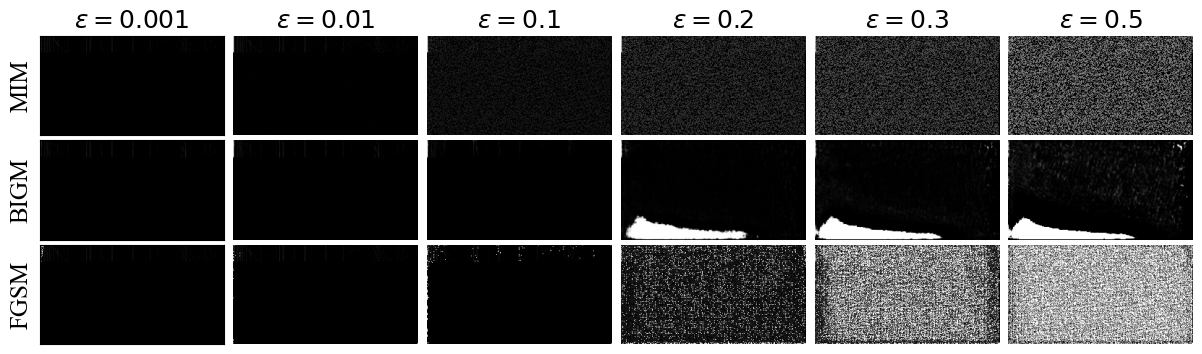

In [127]:
from collections import defaultdict
import cv2

label = "NORMAL"
generator_model = "resnet18_nosampling"
generator_model = "resnet18_normalized_nosampling"
is_normalized = False
data_type = "normalized" if "normalized" in generator_model else "normal"

all_adv = []
all_adv_titles = []

images = [
    i
    for i in adv_block_path.rglob("*.png")
    if label in str(i.name) and generator_model in str(i) and data_type in str(i)
]

atk_names = list(set([i.parent.name for i in images]))
atk_eps = defaultdict(list)
atk_name_map = {}
for atk_name in atk_names:
    atk = (
        "FGSM"
        if "fast" in atk_name
        else "BIGM" if "basic" in atk_name else "MIM" if "momentum" in atk_name else ""
    )
    if atk == "":
        continue
    eps = float(atk_name.split("eps_")[-1])
    atk_name_map[atk] = atk_name.split("_eps")[0]
    atk_eps[atk].append(eps)


ae_models = ["unet_custom", "rdunet"]
ae_images = {}
completed_images = []
for atk, epsilons in atk_eps.items():
    adv_images = []
    unet_adv_images = []
    recon_unet = []
    recon_rdunet = []
    curr_titles = []
    epsilons = sorted(list(set(epsilons)))
    print(epsilons)
    for eps in epsilons:
        atk_folder = (
            adv_block_path
            / generator_model
            / "val"
            / f"{atk_name_map.get(atk)}_eps_{eps}"
        )
        for ae_model in ae_models:
            recon_image = f"{label}_{ae_model}_{data_type}_recon_adversarial.png"
            recon_image_path = atk_folder / recon_image
            adv_image = f"{label}_{ae_model}_{data_type}_adversarial.png"
            adv_image_path = atk_folder / adv_image

            if recon_image_path.exists() and adv_image_path.exists():
                (
                    recon_unet.append(recon_image_path)
                    if ae_model == "unet_custom"
                    else recon_rdunet.append(recon_image_path)
                )
                (
                    unet_adv_images.append(adv_image_path)
                    if ae_model == "unet_custom"
                    else adv_images.append(adv_image_path)
                )
                if ae_model == "unet_custom":
                    all_adv.append(adv_image_path)
                    all_adv_titles.append(f"{atk}({eps})")

                title = f"{atk}({eps})"
                if title not in curr_titles:
                    curr_titles.append(title)

    ncols = len(curr_titles)
    nrows = 3  # [adv_image, unet_recon, rdunet_recon]
    if ncols == 0:
        continue

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3))
    y_labels = ["Adv.", "UNet", "RDUNet"]

    for col in range(ncols):
        # Adversarial images (row 0)
        if col < len(adv_images):
            adv_img = cv2.imread(str(adv_images[col]))
            if adv_img is not None:
                axs[0, col].imshow(cv2.cvtColor(adv_img, cv2.COLOR_BGR2RGB))
            axs[0, col].set_title(curr_titles[col], fontsize=18)
        # UNet reconstructions (row 1)
        if col < len(recon_unet):
            recon_unet_img = cv2.imread(str(recon_unet[col]))
            if recon_unet_img is not None:
                axs[1, col].imshow(cv2.cvtColor(recon_unet_img, cv2.COLOR_BGR2RGB))
        # RDUNet reconstructions (row 2)
        if col < len(recon_rdunet):
            recon_rdunet_img = cv2.imread(str(recon_rdunet[col]))
            if recon_rdunet_img is not None:
                axs[2, col].imshow(cv2.cvtColor(recon_rdunet_img, cv2.COLOR_BGR2RGB))

    # Set y-label and y-ticks only on the left-most image of each row
    for row_idx, y_label in enumerate(y_labels):
        axs[row_idx, 0].set_ylabel(y_label, fontsize=18)
        axs[row_idx, 0].yaxis.set_visible(True)
        axs[row_idx, 0].spines["left"].set_visible(True)
        # Optionally, set larger yticks if you want extra visibility:
        # axs[row_idx, 0].tick_params(axis='y', labelsize=11)

    # Hide axis ticks for all other axes except left-most
    for row in range(nrows):
        for col in range(1, ncols):  # only right of leftmost
            axs[row, col].axis("off")
        # clear ticks from images
        axs[row, 0].set_xticks([])
        axs[row, 0].set_yticks([])
    # plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(
        f"{label}_{data_type}_{generator_model}_{atk}.pdf",
        dpi=300,
        bbox_inches="tight",
    )
    plt.subplots_adjust(hspace=0.05, wspace=0.00)
    plt.show()

# now plot all adversarial images in one figure
ncols = 6
nrows = len(all_adv) // ncols + (1 if len(all_adv) % ncols > 0 else 0)
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, int(1.5 * nrows)))
y_labels = atk_eps.keys()

for col in range(ncols):
    # Adversarial images (row 0)
    if col < len(adv_images):
        adv_img = cv2.imread(str(adv_images[col]))
        if adv_img is not None:
            axs[0, col].imshow(cv2.cvtColor(adv_img, cv2.COLOR_BGR2RGB))
        title = curr_titles[col]
        # only eps part
        title = title.split("(")[1].split(")")[0]
        title = f"$\epsilon={title}$"
        axs[0, col].set_title(title, fontsize=18)
    # UNet reconstructions (row 1)
    if col < len(recon_unet):
        recon_unet_img = cv2.imread(str(recon_unet[col]))
        if recon_unet_img is not None:
            axs[1, col].imshow(cv2.cvtColor(recon_unet_img, cv2.COLOR_BGR2RGB))
    # RDUNet reconstructions (row 2)
    if col < len(recon_rdunet):
        recon_rdunet_img = cv2.imread(str(recon_rdunet[col]))
        if recon_rdunet_img is not None:
            axs[2, col].imshow(cv2.cvtColor(recon_rdunet_img, cv2.COLOR_BGR2RGB))

# Set y-label and y-ticks only on the left-most image of each row
for row_idx, y_label in enumerate(y_labels):
    axs[row_idx, 0].set_ylabel(y_label, fontsize=18)
    axs[row_idx, 0].yaxis.set_visible(True)
    axs[row_idx, 0].spines["left"].set_visible(True)
    axs[row_idx, 0].set_xticks([])
    axs[row_idx, 0].set_yticks([])

# Hide axis for non-leftmost images and remove grid lines/gaps
for row in range(nrows):
    for col in range(1, ncols):
        axs[row, col].axis("off")

plt.subplots_adjust(hspace=0.05, wspace=0.00)

plt.savefig(f"{label}_{data_type}.pdf", dpi=300, bbox_inches="tight")
plt.show()

## From JSON

In [112]:
import json

model_results = {}

for model in models:
    model_name = model.name
    results = model/'results.json'
    if not results.exists():
        continue
    with open(results) as fp:
        results = json.load(fp)
    model_results[model_name]=results
        

In [115]:
model_results

{'mobilenet_v3_large_normalized_nosampling': {'no_attack': {'f1_score': 0.9639418125152588,
   'blocked_f1_score': 0.4160230755805969,
   'mse_loss': 0.0006402666331268847,
   'confusion_matrix': [[128, 0, 0, 0, 38, 0, 0, 0, 0],
    [0, 598, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 665, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 170, 0, 0, 0, 0, 0],
    [60, 0, 0, 2, 3471, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 173, 0, 0, 0],
    [0, 0, 0, 0, 2, 0, 1438, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1403, 37],
    [0, 0, 0, 0, 0, 0, 0, 0, 1440]],
   'blocked_confusion_matrix': [[147, 0, 1, 5, 13, 0, 0, 0, 0],
    [0, 598, 0, 0, 0, 0, 0, 0, 0],
    [0, 361, 304, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 170, 0, 0, 0, 0, 0],
    [1287, 0, 89, 513, 1601, 2, 0, 0, 43],
    [9, 0, 0, 0, 133, 31, 0, 0, 0],
    [1, 0, 0, 30, 136, 0, 207, 0, 1066],
    [18, 0, 0, 4, 96, 0, 0, 135, 1187],
    [1, 0, 0, 8, 38, 0, 0, 0, 1393]]},
  'FastGradientMethod_eps_0.0001': {'f1_score': 0.9104052782058716,
   'blocked_f1_score': 0.4156450033187866,
   

In [105]:
import pandas as pd

all_results = []

for model, results in model_results.items():
    for atk_type, result in results.items():
        if atk_type!='no_attack':
            eps = atk_type.split('eps_')[-1]
            atk_name =  atk_type.split('eps_')[0]
            atk_name = 'FGSM' if 'Fast' in atk_name else 'BIGM'
            eps=float(eps)
        else:
            eps = 0
            atk_name = 'NA'
        f1 = result['f1_score']
        blocked_f1 = result['blocked_f1_score']
        mse_loss = result['mse_loss']
        all_results.append([model, atk_name, eps, f1, blocked_f1, mse_loss])

res_df = pd.DataFrame(all_results, columns=['model','atk', 'eps', 'f1', 'blocked_f1','mse'])
res_df
    

,model,atk,eps,f1,blocked_f1,mse
0,mobilenet_v3_large_normalized_nosampling,NA,0.0000,0.963942,0.416023,0.000640
1,mobilenet_v3_large_normalized_nosampling,FGSM,0.0001,0.910405,0.415645,0.000641
2,mobilenet_v3_large_normalized_nosampling,FGSM,0.0010,0.360729,0.411204,0.000643
3,mobilenet_v3_large_normalized_nosampling,FGSM,0.0100,0.317456,0.405659,0.000653
4,mobilenet_v3_large_normalized_nosampling,FGSM,0.1000,0.058972,0.227177,0.000714
5,mobilenet_v3_large_normalized_nosampling,BIGM,0.0001,0.897192,0.415720,0.000641
6,mobilenet_v3_large_normalized_nosampling,BIGM,0.0010,0.062080,0.411625,0.000642
7,mobilenet_v3_large_normalized_nosampling,BIGM,0.0100,0.020248,0.415548,0.000650
8,mobilenet_v3_large_normalized_nosampling,BIGM,0.1000,0.001857,0.274971,0.000695
9,resnet18_nosampling_adv,NA,0.0000,0.921701,0.812616,0.019462


In [106]:
df = res_df.copy()


In [107]:
df.model.unique()

array(['mobilenet_v3_large_normalized_nosampling',
       'resnet18_nosampling_adv', 'resnet18_normalized_nosampling_adv',
       'resnet18_nosampling', 'resnet18_normalized_nosampling'],
      dtype=object)

In [108]:
def plot_groupped_bars(df:pd.DataFrame, save_as:Path,title:str='F1 and Blocked F1'): 
    
    groups = ['No Attack', 'ε=0.0001', 'ε=0.001', 'ε=0.01', 'ε=0.1']
    
    # Plot style
    sns.set_theme(style="whitegrid", font="serif", rc={
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    for ax, attack in zip(axes, ['FGSM', 'BIGM']):
        records = []
        # Baseline
        base = df[df['atk']=='NA'].iloc[0]
        records += [
            {'group': 'No Attack', 'metric': 'F1',         'score': base['f1']},
            {'group': 'No Attack', 'metric': 'Blocked F1','score': base['blocked_f1']}
        ]
        # Adversarial groups
        for eps in [0.0001, 0.001, 0.01, 0.1]:
            row = df[(df['atk']==attack)&(df['eps']==eps)].iloc[0]
            label = f'ε={eps}'
            records += [
                {'group': label, 'metric': 'F1',         'score': row['f1']},
                {'group': label, 'metric': 'Blocked F1','score': row['blocked_f1']}
            ]
        plot_df = pd.DataFrame.from_records(records)
    
        sns.barplot(
            data=plot_df,
            x='group',
            y='score',
            hue='metric',
            ax=ax,
            palette=['#2E86AB', '#A0C5E8'],
            edgecolor='black'
        )
        ax.set_title(f'{attack} Attack')
        ax.set_xlabel('')
        if ax is axes[0]:
            ax.set_ylabel('Score')
        else:
            ax.set_ylabel('')
        ax.set_ylim(0, 1.0)
        ax.set_yticks([i/10 for i in range(0, 11)])
        ax.grid(axis='y', linestyle='--', color='gray', alpha=0.5)
    
        # Annotate
        for p in ax.patches:
            h = p.get_height()
            # Only annotate if height is meaningful
            if h < 0.01:
                continue
            ax.annotate(f'{h:.2f}',
                        (p.get_x() + p.get_width() / 2, h),
                        ha='center', va='bottom', fontsize=10)
        ax.legend(title='Metric')
    
    # Final touches
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(save_as, dpi=300)
    plt.show()



mobilenet_v3_large_normalized_nosampling


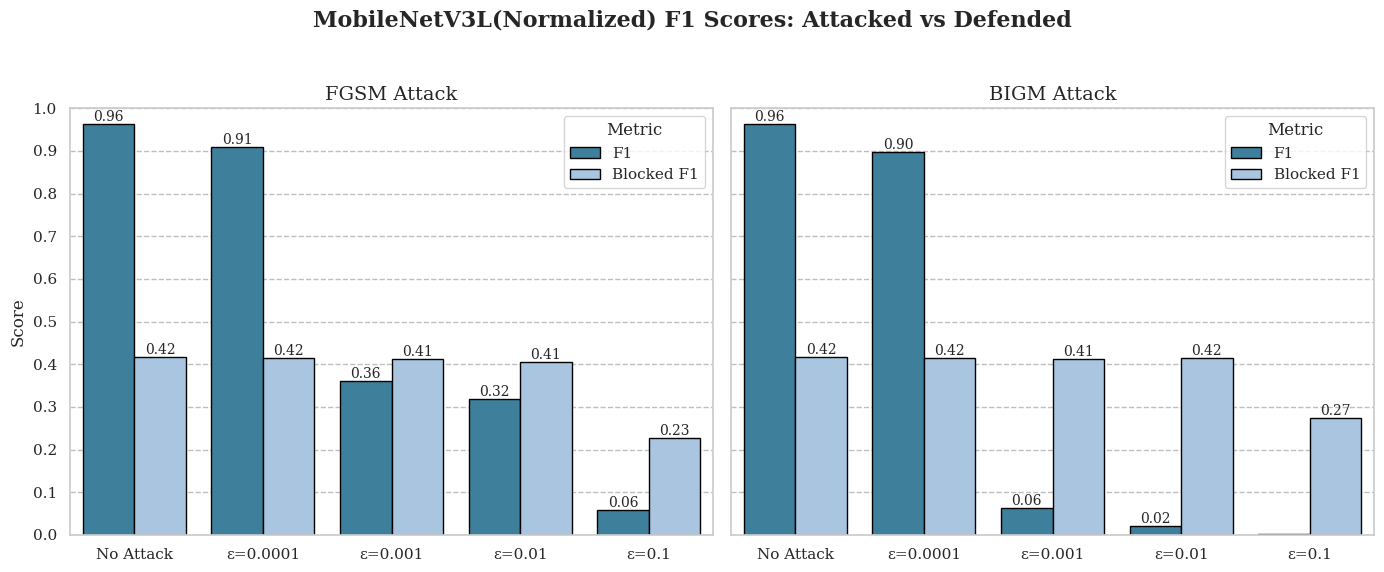

resnet18_nosampling_adv


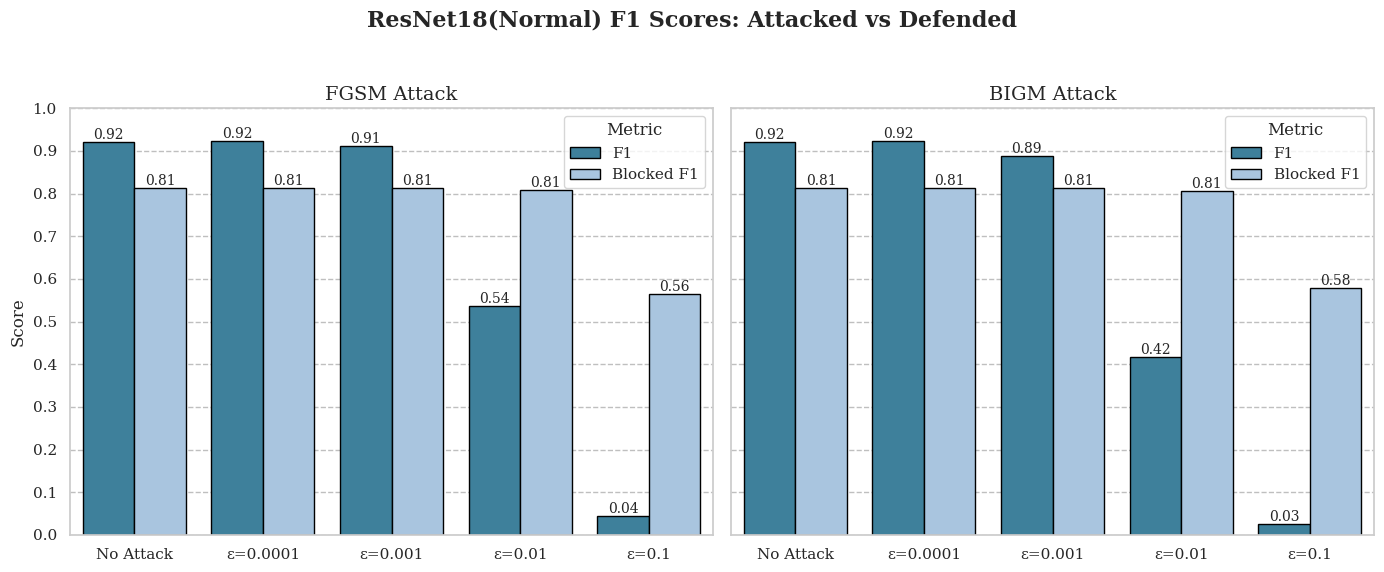

resnet18_normalized_nosampling_adv


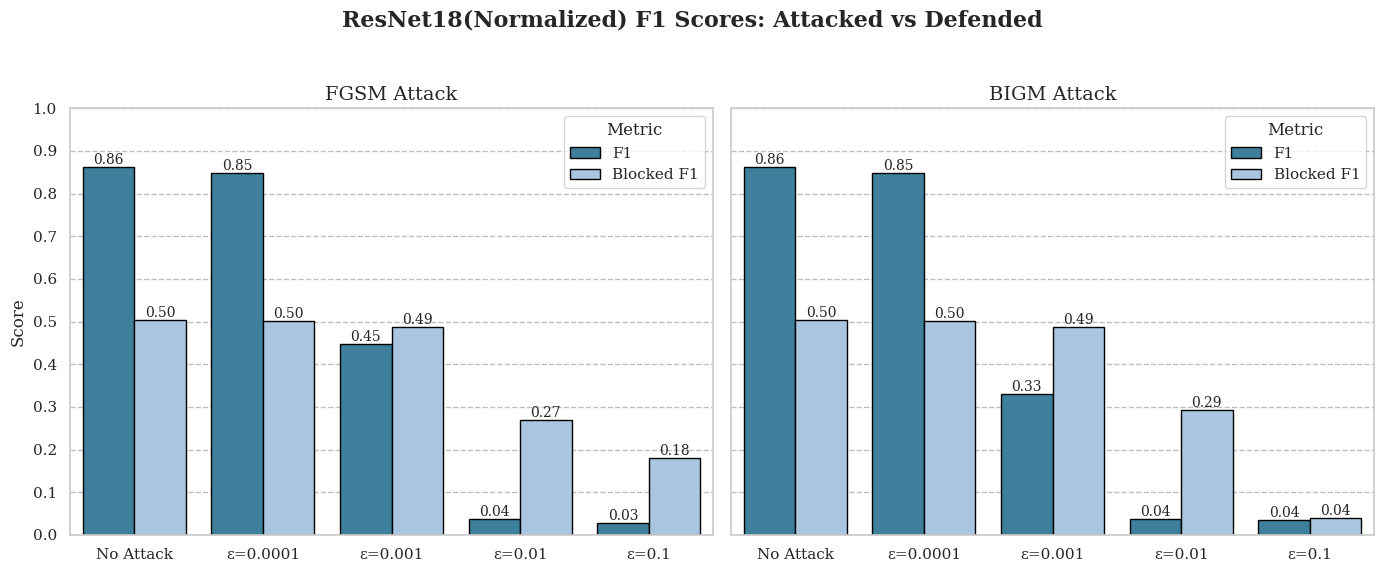

resnet18_nosampling


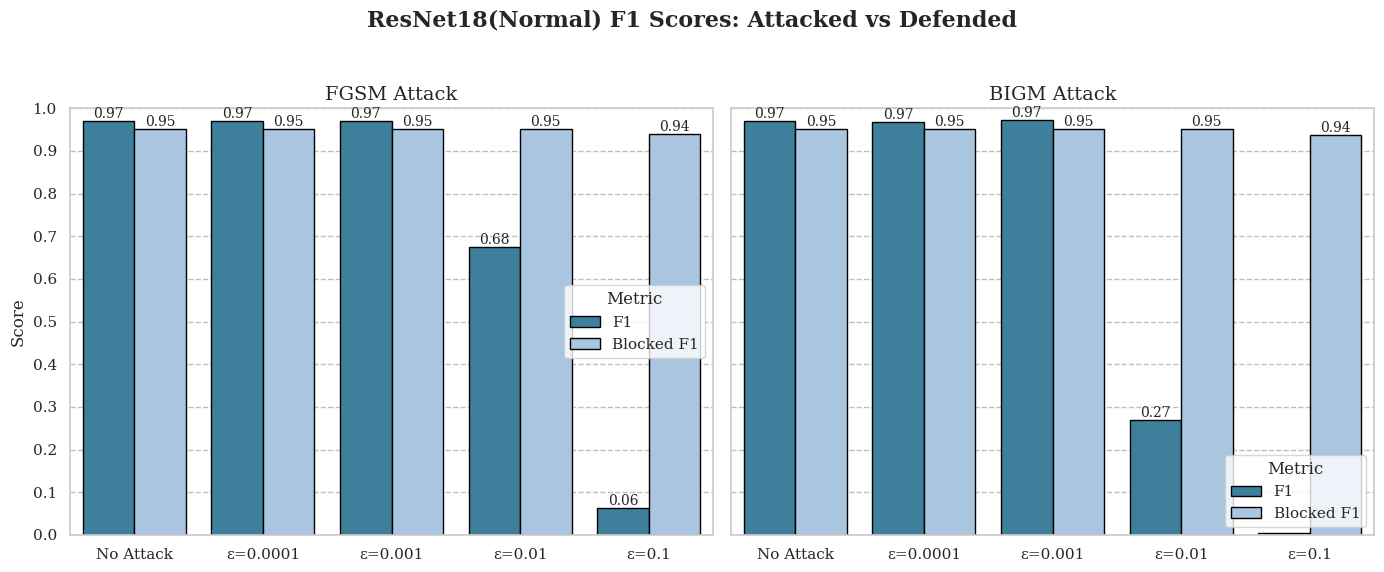

resnet18_normalized_nosampling


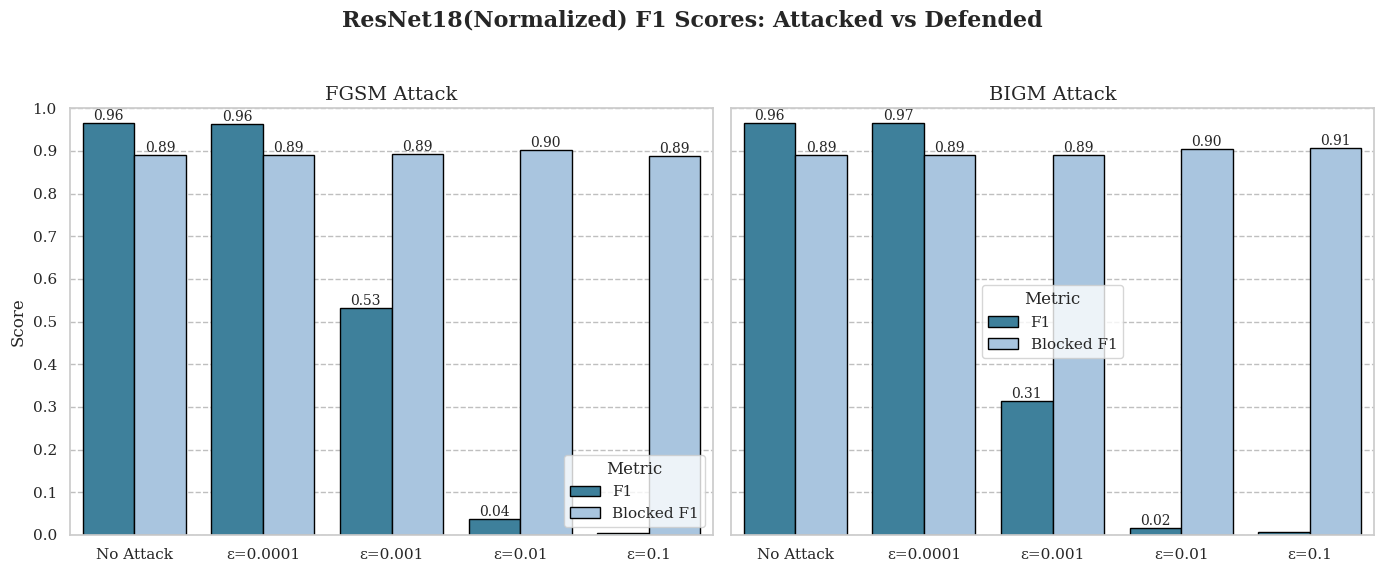

In [109]:
for model_name in df.model.unique():
    print(model_name)
    ndf = df.query('model==@model_name')
    backbone = 'ResNet18' if 'resnet' in model_name else 'MobileNetV3L'
    data_type = 'Normalized' if 'normalized' in model_name.lower() else 'Normal'
    title_name = f'{backbone}({data_type})'
    plot_groupped_bars(ndf, title=f'{title_name} F1 Scores: Attacked vs Defended',save_as=save_dir/f'{model_name}.pdf')

## Model Parameters

In [273]:
import os
import sys
import torch
import json


models = [f for f in Path('../results/').rglob('*best_model_full.pth*')]

model_params = {}

for model in models:
    try:
        model_name = model.parent.name.lower()
        model_name = 'rdunet' if 'rdunet' in model_name else 'unet' if 'unet' in model_name else 'resnet18' if 'resnet' in model_name else 'mobilenetv3l' if 'mobilenet' in model_name else ''
        if model_name=='':
            continue
        model = torch.load(model, map_location='cpu', weights_only=False)
        total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        model_params[model_name]=total_params
        # print(f"Total trainable parameters {model_name}: {total_params}")
    except Exception as e:
        pass

epoch_times = {}

print(model_params)

{'rdunet': 41602690, 'unet': 24430097, 'mobilenetv3l': 4213273, 'resnet18': 11174857}


In [274]:
from collections import defaultdict
import re
log_files = [f for f in Path('../results/').rglob('*/trainer.log')]
print(f"Found {len(log_files)}")
# Pattern to extract the learning rate
pattern = re.compile(r'Learning rate:\s*([0-9.eE-]+)')
learning_rates = defaultdict(list)
epoch_seconds = {}

for logfile in log_files:
    model_name=logfile.parent.name
    model_name = 'rdunet' if 'rdunet' in model_name else 'unet' if 'unet' in model_name else 'resnet18' if 'resnet' in model_name else 'mobilenetv3l' if 'mobilenet' in model_name else ''
    if model_name=='':
        continue
    print(model_name)
    with open(logfile, 'r') as f:
        lines = f.readlines()
    # parse times
    start_time = pd.to_datetime(lines[0].split('|')[0])
    end_time = pd.to_datetime(lines[-1].split('|')[0])
    # collect LRs
    for line in lines:
        match = pattern.search(line)
        if match:
            lr = float(match.group(1))
            learning_rates[model_name].append(lr
                                             )
            
    # compute avg seconds per epoch
    try:
        num_epochs = len(learning_rates[model_name])
        total_seconds = (end_time - start_time).total_seconds()
        epoch_seconds[model_name] = total_seconds / num_epochs
    except:
        pass
epoch_seconds

Found 16
rdunet
rdunet
unet
unet
mobilenetv3l
mobilenetv3l
mobilenetv3l
resnet18
resnet18
resnet18
resnet18
mobilenetv3l


{'rdunet': 60.863779970401694,
 'unet': 24.607697303805367,
 'mobilenetv3l': 62.061872251170044,
 'resnet18': 181.83173848187633}

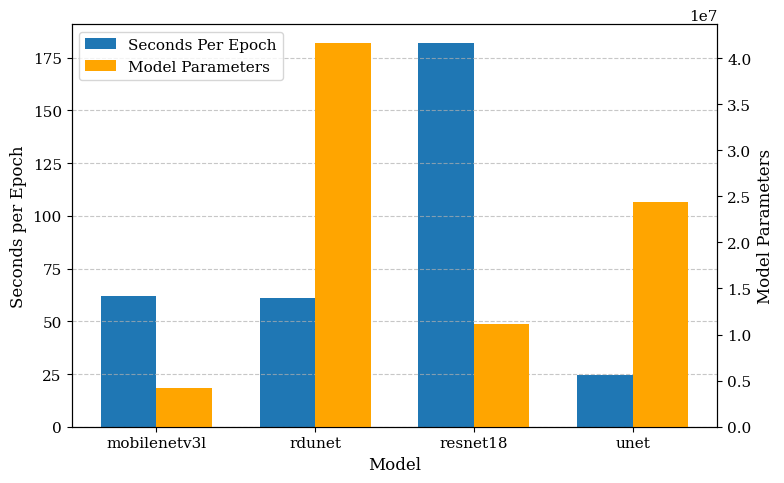

In [275]:
d1=epoch_seconds
d2 = model_params
sorted_keys = sorted(d1.keys())
vals1 = [d1[k] for k in sorted_keys]
vals2 = [d2[k] for k in sorted_keys]

x = np.arange(len(sorted_keys))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))
bars1 = ax1.bar(x - width/2, vals1, width, label='Run 1')
ax1.set_ylabel('Seconds per Epoch')
ax1.set_xticks(x)
ax1.set_xticklabels(sorted_keys)
ax1.set_xlabel('Model')
# ax1.set_title('Grouped Barplot by Model')
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# Second y-axis (identical style)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, vals2, width, label='Run 2', color='orange')
ax2.set_ylabel('Model Parameters')

# def label_bars(bars, ax):
#     for bar in bars:
#         height = bar.get_height()
#         ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', 
#                 ha='center', va='bottom')

# label_bars(bars1, ax1)
# label_bars(bars2, ax2)

fig.tight_layout()
ax1.legend([bars1, bars2], ['Seconds Per Epoch', 'Model Parameters'], loc='upper left')
plt.savefig('epoch_sec_params.pdf')
plt.show()

## From CSV

### Attack Clf

In [276]:
import pandas as pd

In [377]:
image_clf_path = Path('../results/image_classification')
metrics_files = [f for f in image_clf_path.rglob('*.csv') if 'adv' not in str(f)]
log_files = [f for f in image_clf_path.rglob('*.log') if 'adv' not in str(f)]
metrics_files, log_files


([PosixPath('../results/image_classification/mobilenet_v3_large_normalized_nosampling/metrics.csv'),
  PosixPath('../results/image_classification/mobilenet_v3_large_nosampling/metrics.csv'),
  PosixPath('../results/image_classification/resnet18_nosampling/metrics.csv'),
  PosixPath('../results/image_classification/resnet18_normalized_nosampling/metrics.csv')],
 [PosixPath('../results/image_classification/mobilenet_v3_large_normalized_nosampling/trainer.log'),
  PosixPath('../results/image_classification/mobilenet_v3_large_nosampling/trainer.log'),
  PosixPath('../results/image_classification/resnet18_nosampling/trainer.log'),
  PosixPath('../results/image_classification/resnet18_normalized_nosampling/trainer.log')])

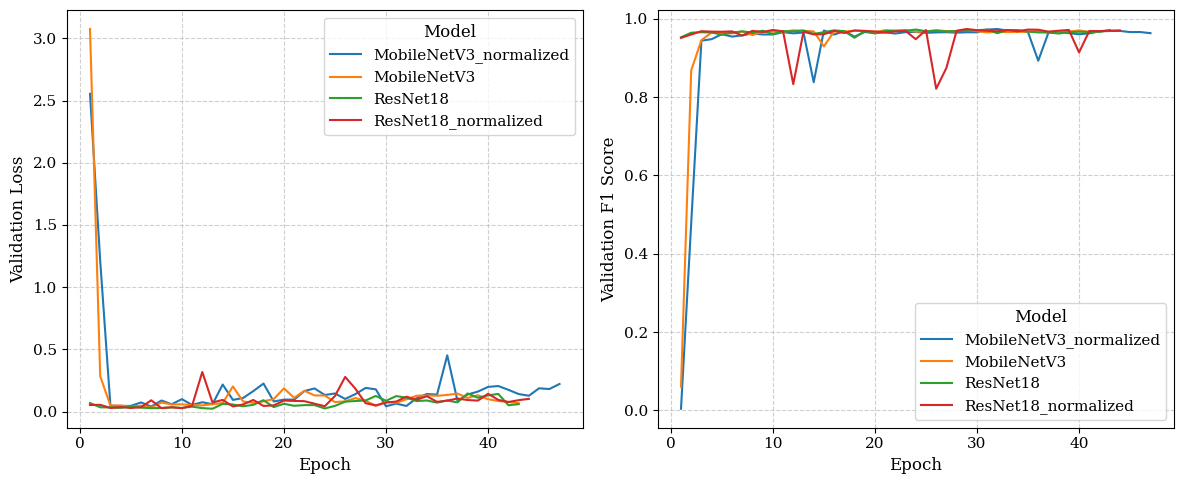

In [378]:
data_type='normalized'
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot each file's metrics
for filepath in metrics_files:
    label='ResNet18' if 'resnet' in str(filepath).lower() else 'MobileNetV3'
    if data_type in str(filepath).lower():
        label=label+'_normalized'
    
    df = pd.read_csv(filepath)
    axs[0].plot(df['epoch'], df['val_loss'],  label=label)
    axs[1].plot(df['epoch'], df['val_f1_score'], label=label)

# Academic plot styling
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Validation Loss')
# axs[0].set_title('Validation Loss over Epochs')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend(title='Model')

axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Validation F1 Score')
# axs[1].set_title('Validation F1 Score over Epochs')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend(title='Model')
plt.savefig('val_loss_f1_atk_clf.pdf')
plt.tight_layout()
plt.show()

{'mobilenet_v3_large_normalized_nosampling': 1824.3756706595743, 'mobilenet_v3_large_nosampling': 1969.416454023256, 'resnet18_nosampling': 2005.3345353255813, 'resnet18_normalized_nosampling': 1938.1610306363634}


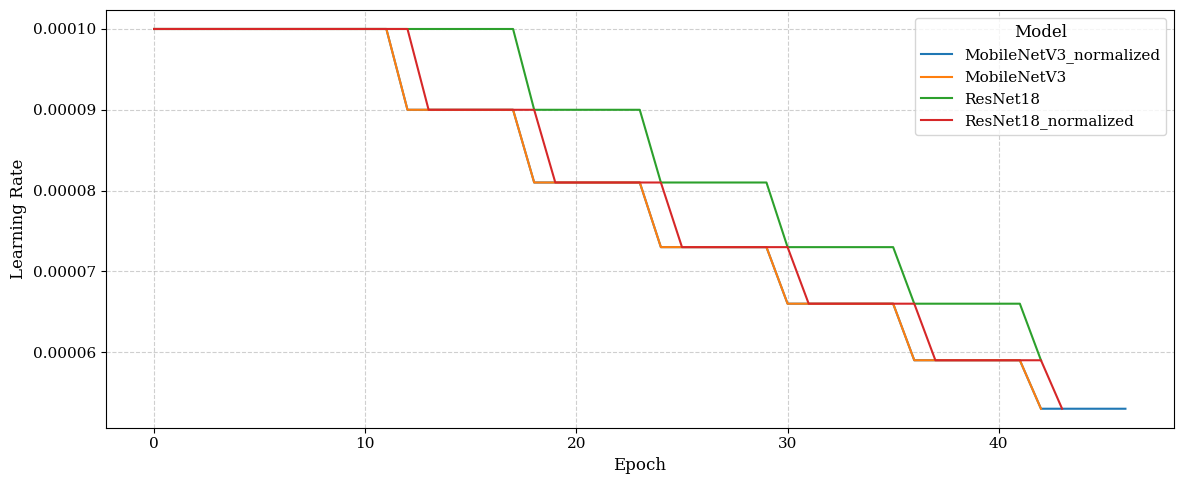

In [379]:
from collections import defaultdict
import re
# Pattern to extract the learning rate
pattern = re.compile(r'Learning rate:\s*([0-9.eE-]+)')
learning_rates = defaultdict(list)
epoch_seconds = {}

for logfile in log_files:
    with open(logfile, 'r') as f:
        lines = f.readlines()
    # parse times
    start_time = pd.to_datetime(lines[0].split('|')[0])
    end_time = pd.to_datetime(lines[-1].split('|')[0])
    # collect LRs
    for line in lines:
        match = pattern.search(line)
        if match:
            lr = float(match.group(1))
            learning_rates[logfile.parent.name].append(lr)
    # compute avg seconds per epoch
    num_epochs = len(learning_rates[logfile.parent.name])
    total_seconds = (end_time - start_time).total_seconds()
    epoch_seconds[logfile.parent.name] = total_seconds / num_epochs
print(epoch_seconds)
data_type='normalized'
fig = plt.figure(figsize=(12, 5))

for log_file, lrs in learning_rates.items():
    label='ResNet18' if 'resnet' in str(log_file).lower() else 'MobileNetV3'
    if data_type in str(log_file).lower():
        label=label+'_normalized'
    
    epochs = list(range(len(lrs)))
    
    plt.plot(epochs, lrs,  label=label)

# Academic plot styling
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Model')
plt.savefig('lr_per_epoch_atk_clf.pdf')
plt.tight_layout()
plt.show()

#### Training Time

### Adversarial Training

In [380]:
metrics_files = [f for f in image_clf_path.rglob('*.csv') if 'adv' in str(f)]
log_files = [f for f in image_clf_path.rglob('*.log') if 'adv' in str(f)]
metrics_files, log_files

([PosixPath('../results/image_classification/mobilenet_v3_large_normalized_nosampling_adv/metrics.csv'),
  PosixPath('../results/image_classification/resnet18_nosampling_adv/metrics.csv'),
  PosixPath('../results/image_classification/resnet18_normalized_nosampling_adv/metrics.csv'),
  PosixPath('../results/image_classification/mobilenet_v3_large_nosampling_adv/metrics.csv')],
 [PosixPath('../results/image_classification/mobilenet_v3_large_normalized_nosampling_adv/trainer.log'),
  PosixPath('../results/image_classification/resnet18_nosampling_adv/trainer.log'),
  PosixPath('../results/image_classification/resnet18_normalized_nosampling_adv/trainer.log'),
  PosixPath('../results/image_classification/mobilenet_v3_large_nosampling_adv/trainer.log')])

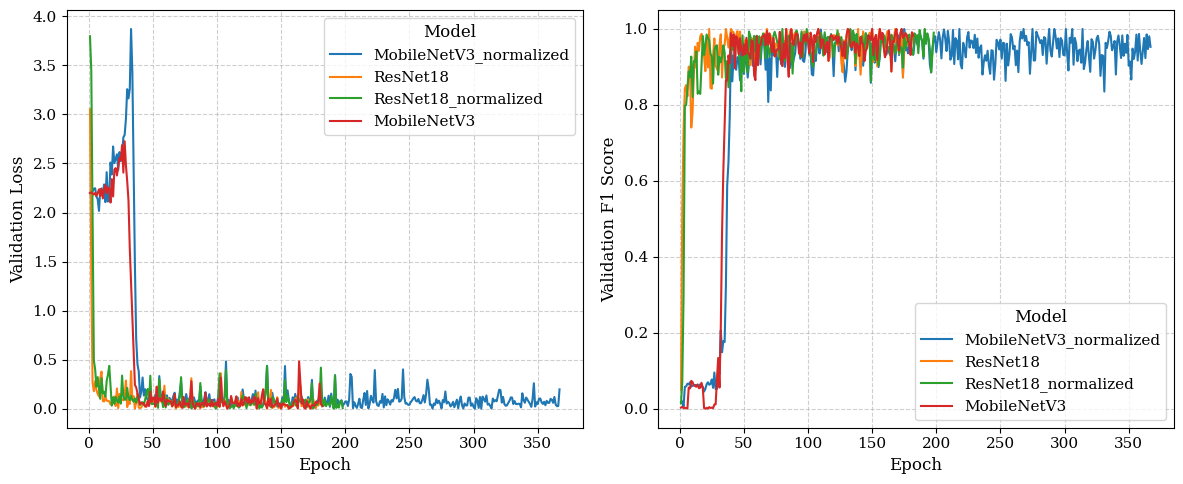

In [381]:
data_type='normalized'
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot each file's metrics
for filepath in metrics_files:
    label='ResNet18' if 'resnet' in str(filepath).lower() else 'MobileNetV3'
    if data_type in str(filepath).lower():
        label=label+'_normalized'
    
    df = pd.read_csv(filepath)
    axs[0].plot(df['epoch'], df['val_loss'],  label=label)
    axs[1].plot(df['epoch'], df['val_f1_score'], label=label)

# Academic plot styling
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Validation Loss')
# axs[0].set_title('Validation Loss over Epochs')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend(title='Model')

axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Validation F1 Score')
# axs[1].set_title('Validation F1 Score over Epochs')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend(title='Model')
plt.savefig('val_loss_f1_atk_clf_atc.pdf')
plt.tight_layout()
plt.show()

{'mobilenet_v3_large_normalized_nosampling_adv': 187.2548554076087, 'resnet18_nosampling_adv': 217.410736136612, 'resnet18_normalized_nosampling_adv': 206.5787277788945, 'mobilenet_v3_large_nosampling_adv': 217.38612083606557}


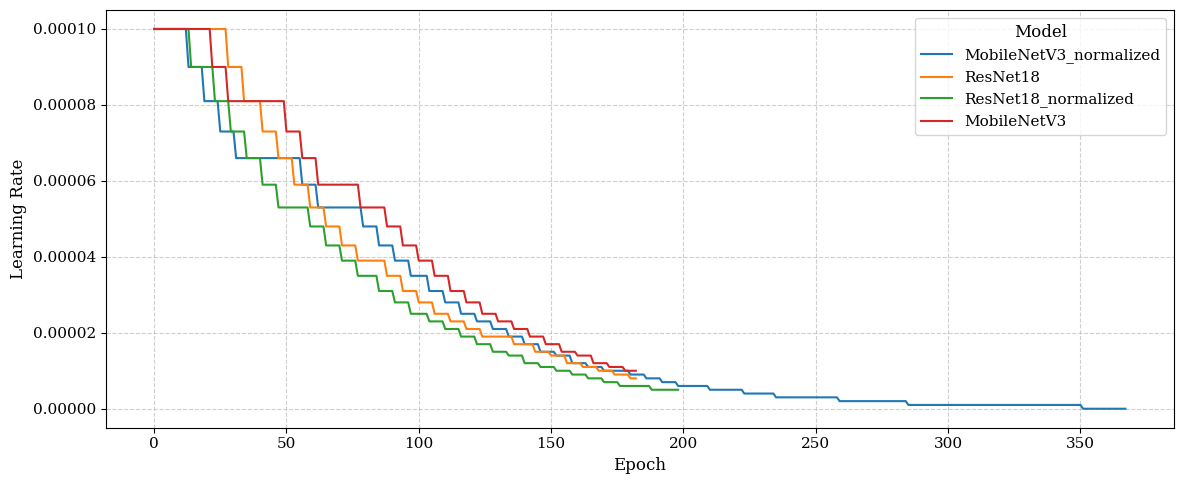

In [382]:
from collections import defaultdict
import re
# Pattern to extract the learning rate
pattern = re.compile(r'Learning rate:\s*([0-9.eE-]+)')
learning_rates=defaultdict(list)
epoch_seconds = {}

for logfile in log_files:
    with open(logfile, 'r') as f:
        lines = f.readlines()
    # parse times
    start_time = pd.to_datetime(lines[0].split('|')[0])
    end_time = pd.to_datetime(lines[-1].split('|')[0])
    # collect LRs
    for line in lines:
        match = pattern.search(line)
        if match:
            lr = float(match.group(1))
            learning_rates[logfile.parent.name].append(lr)
    # compute avg seconds per epoch
    num_epochs = len(learning_rates[logfile.parent.name])
    total_seconds = (end_time - start_time).total_seconds()
    epoch_seconds[logfile.parent.name] = total_seconds / num_epochs
print(epoch_seconds)

data_type='normalized'
fig = plt.figure(figsize=(12, 5))

for log_file, lrs in learning_rates.items():
    label='ResNet18' if 'resnet' in str(log_file).lower() else 'MobileNetV3'
    if data_type in str(log_file).lower():
        label=label+'_normalized'
    
    epochs = list(range(len(lrs)))
    
    plt.plot(epochs, lrs,  label=label)

# Academic plot styling
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Model')
plt.savefig('lr_per_epoch_atk_clf_adv.pdf')
plt.tight_layout()
plt.show()

### Adversarial Blocking Models

In [383]:
ae_path=Path('../results/autoencoder')
metrics_files = [f for f in ae_path.rglob('*.csv')]
log_files = [f for f in ae_path.rglob('*.log')]
metrics_files, log_files

([PosixPath('../results/autoencoder/rdunet_normalized/metrics.csv'),
  PosixPath('../results/autoencoder/rdunet_normal/metrics.csv'),
  PosixPath('../results/autoencoder/unet_custom_normal/metrics.csv'),
  PosixPath('../results/autoencoder/unet_custom_normalized/metrics.csv')],
 [PosixPath('../results/autoencoder/rdunet_normalized/trainer.log'),
  PosixPath('../results/autoencoder/rdunet_normal/trainer.log'),
  PosixPath('../results/autoencoder/unet_custom_normal/trainer.log'),
  PosixPath('../results/autoencoder/unet_custom_normalized/trainer.log')])

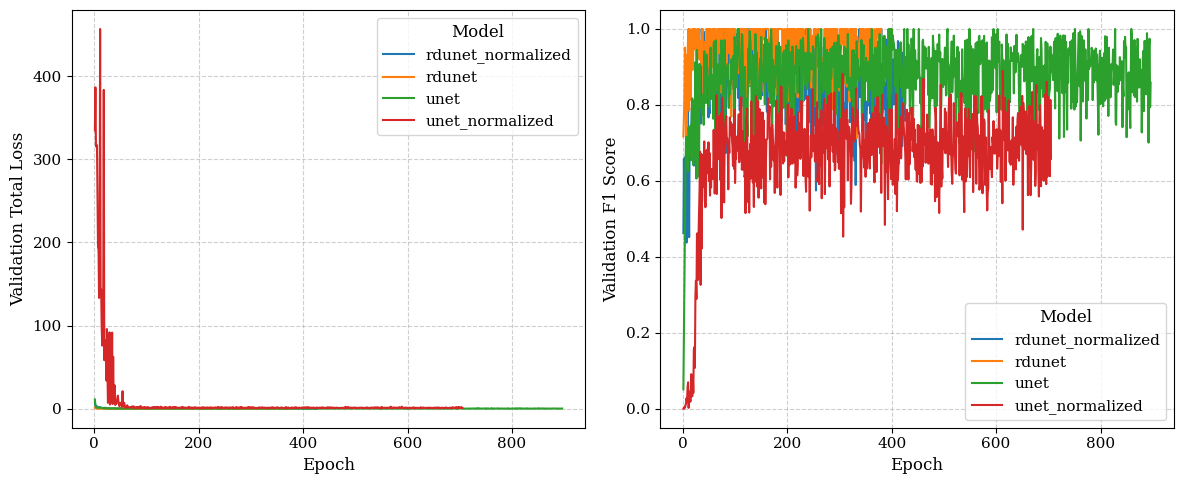

In [384]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot each file's metrics
for filepath in metrics_files:
    df = pd.read_csv(filepath)
    label = 'rdunet' if 'rdunet' in str(filepath) else 'unet'
    label = label+'_normalized' if 'normalized' in str(filepath) else label
    axs[0].plot(df['epoch'], df['val_total_loss'],  label=label)
    axs[1].plot(df['epoch'], df['val_rec_f1'], label=label)

# Academic plot styling
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Validation Total Loss')
# axs[0].set_title('Validation Total Loss over Epochs')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend(title='Model')

axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Validation F1 Score')
# axs[1].set_title('Validation F1 Score over Epochs')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend(title='Model')
plt.savefig('val_loss_f1_ae.pdf')
plt.tight_layout()
plt.show()

{'rdunet_normalized': 114.91395406272402, 'rdunet_normal': 129.44098082020201, 'unet_custom_normal': 58.3235134057971, 'unet_custom_normalized': 55.87271781586402}


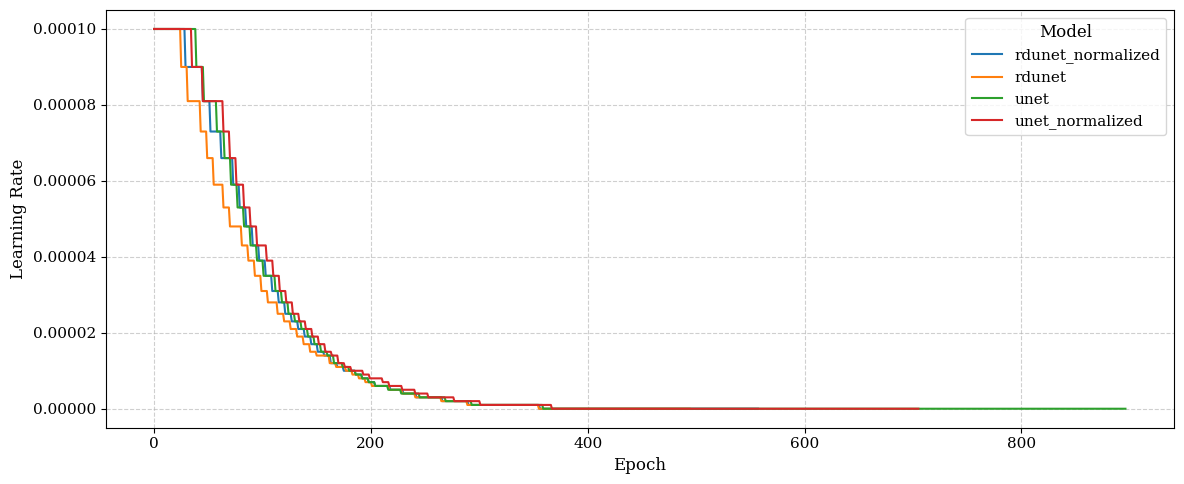

In [385]:
from collections import defaultdict
import re
# Pattern to extract the learning rate
pattern = re.compile(r'Learning rate:\s*([0-9.eE-]+)')
learning_rates=defaultdict(list)
epoch_seconds = {}

for logfile in log_files:
    with open(logfile, 'r') as f:
        lines = f.readlines()
    # parse times
    start_time = pd.to_datetime(lines[0].split('|')[0])
    end_time = pd.to_datetime(lines[-1].split('|')[0])
    # collect LRs
    for line in lines:
        match = pattern.search(line)
        if match:
            lr = float(match.group(1))
            learning_rates[logfile.parent.name].append(lr)
    # compute avg seconds per epoch
    num_epochs = len(learning_rates[logfile.parent.name])
    total_seconds = (end_time - start_time).total_seconds()
    epoch_seconds[logfile.parent.name] = total_seconds / num_epochs
print(epoch_seconds)

data_type='normalized'
fig = plt.figure(figsize=(12, 5))

for filepath, lrs in learning_rates.items():    
    label = 'rdunet' if 'rdunet' in str(filepath) else 'unet'
    label = label+'_normalized' if 'normalized' in str(filepath) else label
    
    epochs = list(range(len(lrs)))
    
    plt.plot(epochs, lrs,  label=label)

# Academic plot styling
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Model')
plt.savefig('lr_per_epoch_ae.pdf')
plt.tight_layout()
plt.show()

### Evaluation Results

In [386]:
eval_dir = Path('../results/adversarial_blocking')

csv_files = [f for f in eval_dir.rglob('*.csv')]
csv_files

[PosixPath('../results/adversarial_blocking/mobilenet_v3_large_normalized_nosampling/evaluation_results_normalized_val.csv'),
 PosixPath('../results/adversarial_blocking/mobilenet_v3_large_nosampling/evaluation_results_normal_val.csv'),
 PosixPath('../results/adversarial_blocking/resnet18_nosampling/evaluation_results_normal_val.csv'),
 PosixPath('../results/adversarial_blocking/resnet18_normalized_nosampling/evaluation_results_normalized_val.csv')]

In [387]:
import pandas as pd
import numpy as np

def plot_bars(bars, name='plot.pdf', show=True):
    # Convert to DataFrame for easier handling
    mdf = pd.DataFrame(bars)  # Your metrics dictionary
    atk_names = mdf.columns
    mdf = mdf.T
    mdf['atk_name'] = atk_names
    mdf['eps'] = mdf['atk_name'].apply(lambda x: 0 if '(' not in x else float(x.split('(')[-1].split(')')[0]))
    mdf = mdf.sort_values(['eps', 'atk_name'])
    
    # Clean up temporary columns
    del mdf['eps']
    del mdf['atk_name']
    
    # Wrap text in index names (attack types)
    new_index = []
    for idx in mdf.index:
        if '(' in idx:
            i = idx.index('(')
            new_idx = idx[:i].strip() + '\n' + idx[i:]
            new_index.append(new_idx)
        else:
            new_index.append(idx)
    mdf.index = new_index
    
    # Separate F1 and MAE metrics
    f1_cols = [col for col in mdf.columns if 'f1' in col]
    mae_cols = [col for col in mdf.columns if 'mae' in col]
    
    # Calculate uniform bar width based on total number of metrics
    total_metrics = len(f1_cols) + len(mae_cols)
    uniform_bar_width = 0.8 / total_metrics  # 0.8 is total space for bars
    
    # Create the dual-axis grouped bar plot
    x = np.arange(len(mdf))
    
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # Plot F1 metrics with uniform bar width
    for i, col in enumerate(f1_cols):
        offset = (i - (total_metrics-1)/2) * uniform_bar_width
        ax1.bar(x + offset, mdf[col], width=uniform_bar_width, label=col)
    
    ax1.set_ylabel('F1 Score')
    ax1.set_xlabel('Attack Type')
    ax1.set_xticks(x)
    ax1.set_xticklabels(mdf.index, rotation=0, ha='center', fontsize=10)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Right axis: MAE metrics with same uniform bar width
    ax2 = ax1.twinx()
    for i, col in enumerate(mae_cols):
        # Continue the offset from where F1 bars ended
        offset = ((len(f1_cols) + i) - (total_metrics-1)/2) * uniform_bar_width
        ax2.bar(x + offset, mdf[col], width=uniform_bar_width, label=col, alpha=0.7, hatch='//')
    
    ax2.set_ylabel('MAE')
    
    # Combine legends from both axes
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper right', fontsize=10, ncol=2)
    
    # Remove extra horizontal padding:
    half_group = (total_metrics * uniform_bar_width) / 2+0.1
    ax1.set_xlim(x[0] - half_group, x[-1] + half_group)

    
    # Set y-axis major ticks at 0.1 intervals on left (F1 axis)
    ax1.set_yticks(np.arange(0, 1.01, 0.1))
    ax1.grid(axis='y', which='major', linestyle='--', alpha=0.7)
    
    # Set right y-axis major ticks at appropriate interval (e.g., 0.1 for MAE if in [0,1])
    # ax2.set_yticks(np.arange(0, ax2.get_ylim()[1] + 0.01, 0.1))
    ax2.grid(axis='y', which='major', linestyle=':', alpha=0.5)
    
    # If you also want vertical grid every 0.1 group spacing:
    ax1.set_xticks(x, minor=False)
    ax1.xaxis.grid(True, which='major', linestyle='--', alpha=0.3)

    
    plt.tight_layout()
    plt.savefig(name)
    if show:
        plt.show()
    return mdf, fig



#### Only FGM, BIGM [0.01, 0.1]

mobilenet_v3_large_normalized_nosampling
0 train_mobilenet_v3_large_normalized_nosampling_resnet.pdf
1 train_mobilenet_v3_large_normalized_nosampling_mobilenet.pdf
mobilenet_v3_large_nosampling
2 train_mobilenet_v3_large_nosampling_resnet.pdf
3 train_mobilenet_v3_large_nosampling_mobilenet.pdf
resnet18_nosampling
4 train_resnet18_nosampling_resnet.pdf
5 train_resnet18_nosampling_mobilenet.pdf
resnet18_normalized_nosampling
6 train_resnet18_normalized_nosampling_resnet.pdf
7 train_resnet18_normalized_nosampling_mobilenet.pdf
mobilenet_v3_large_normalized_nosampling
0 test_mobilenet_v3_large_normalized_nosampling_resnet.pdf
1 test_mobilenet_v3_large_normalized_nosampling_mobilenet.pdf
mobilenet_v3_large_nosampling
2 test_mobilenet_v3_large_nosampling_resnet.pdf
3 test_mobilenet_v3_large_nosampling_mobilenet.pdf
resnet18_nosampling
4 test_resnet18_nosampling_resnet.pdf
5 test_resnet18_nosampling_mobilenet.pdf
resnet18_normalized_nosampling
6 test_resnet18_normalized_nosampling_resnet.pdf


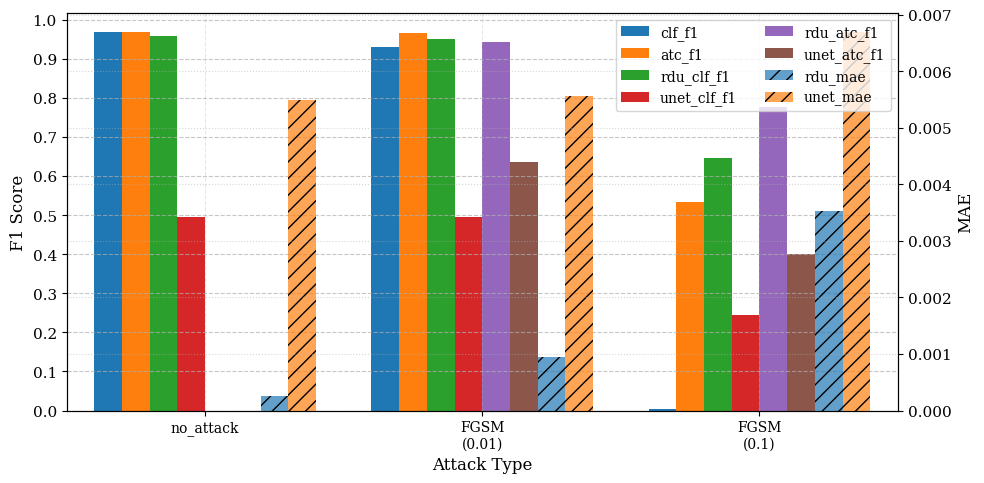

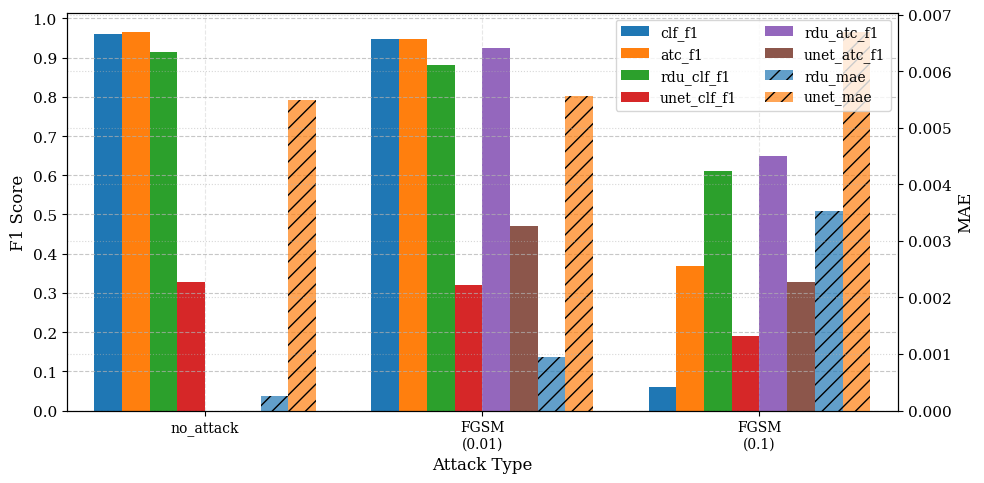

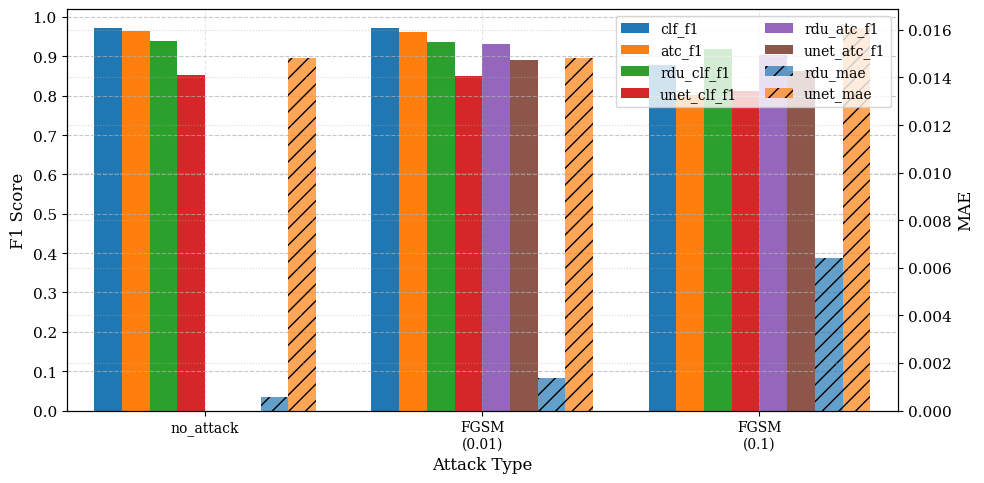

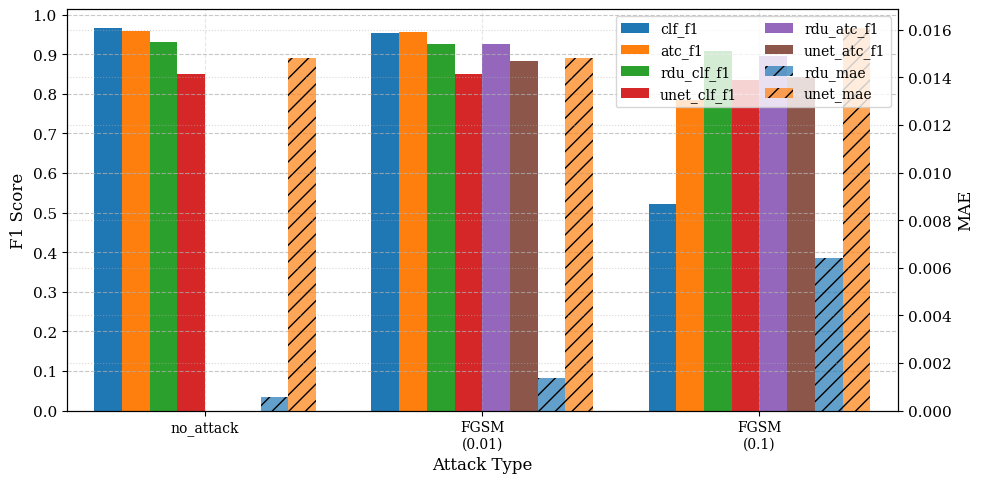

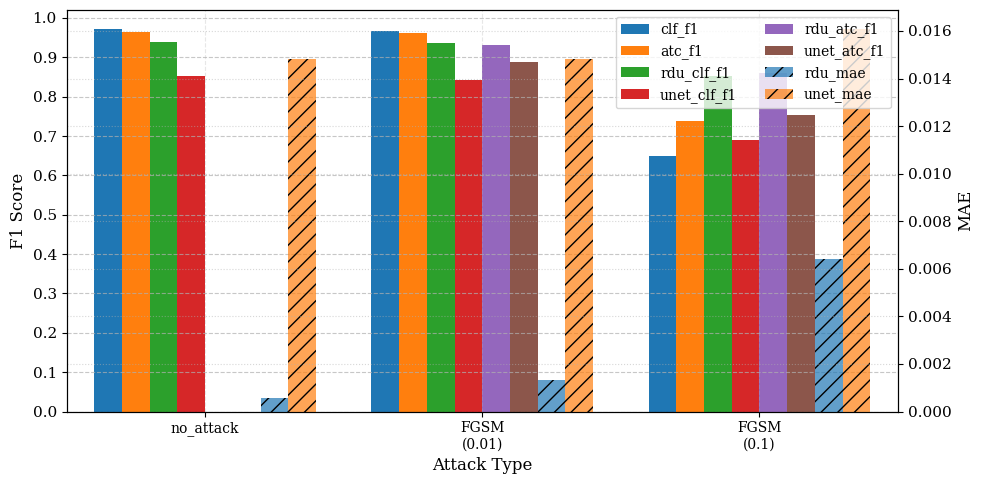

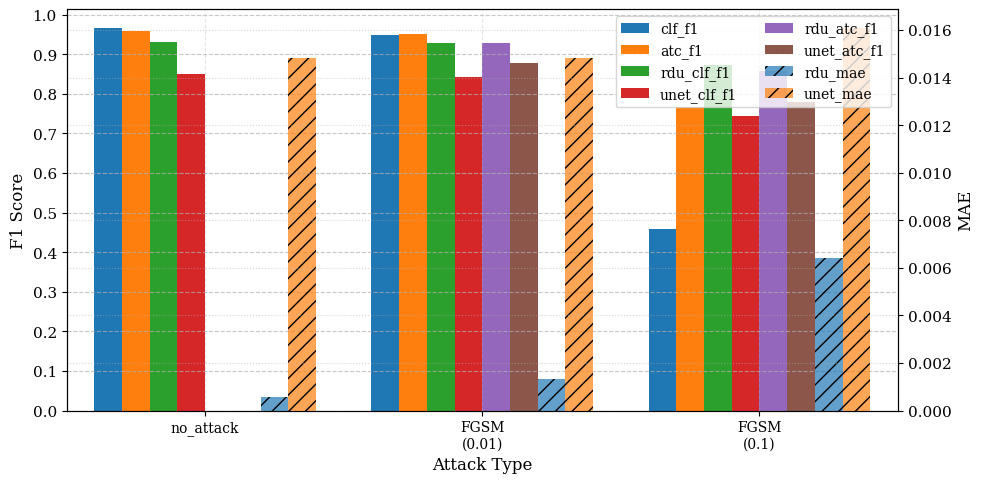

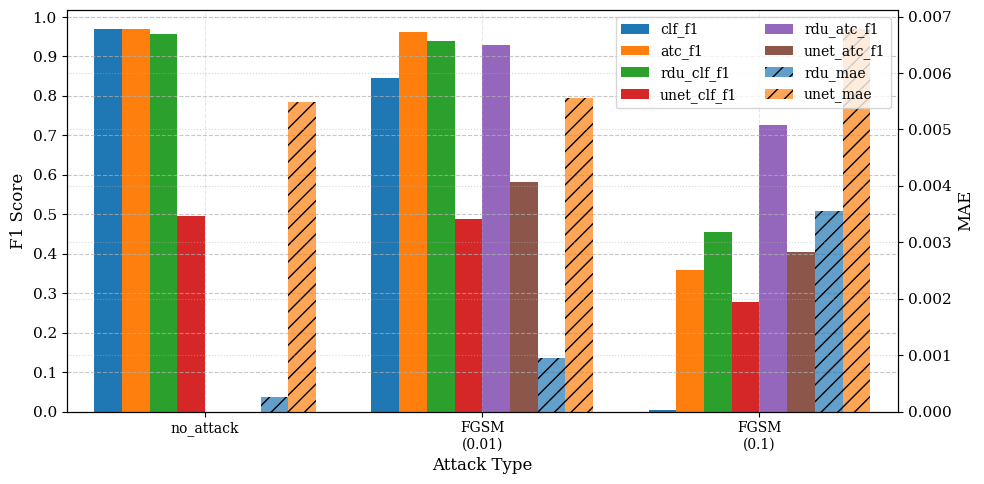

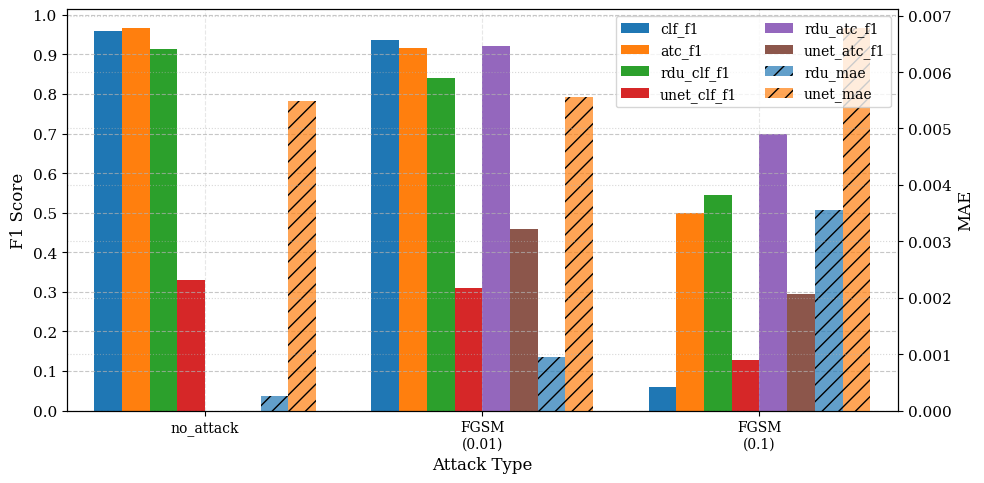

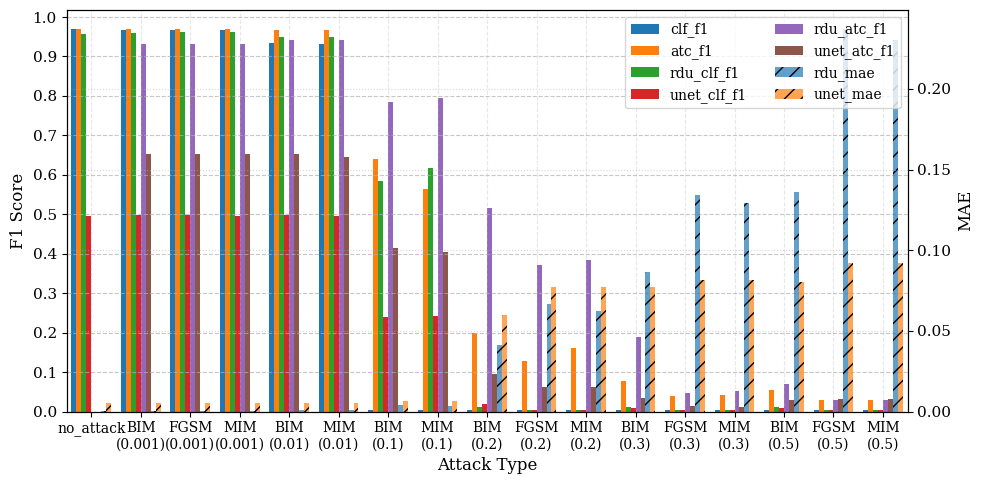

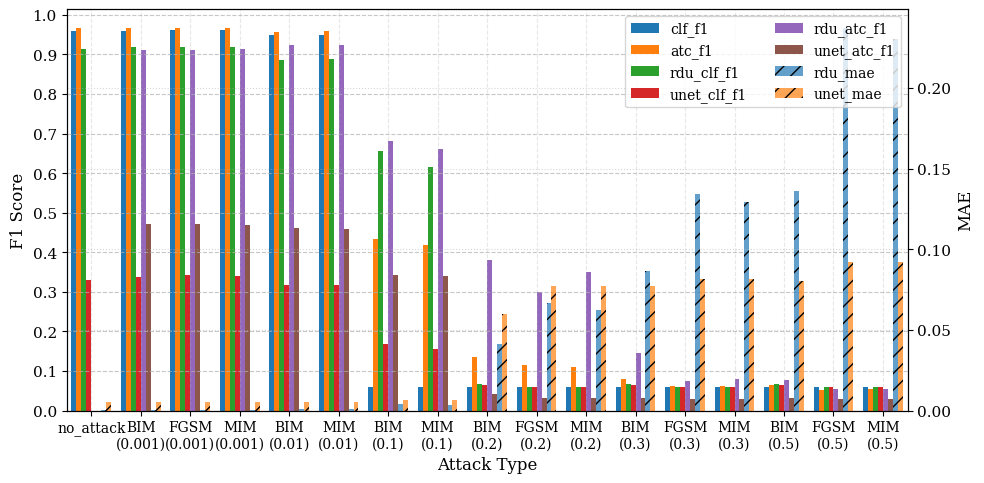

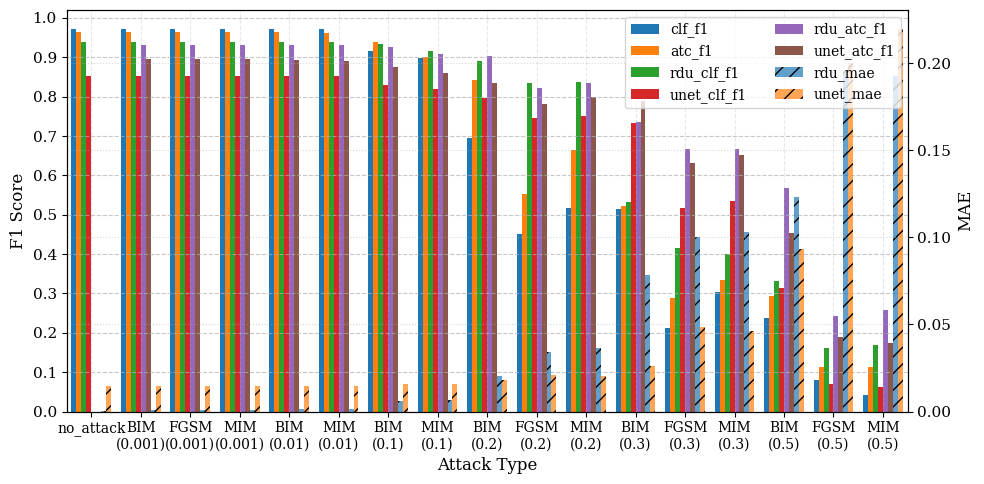

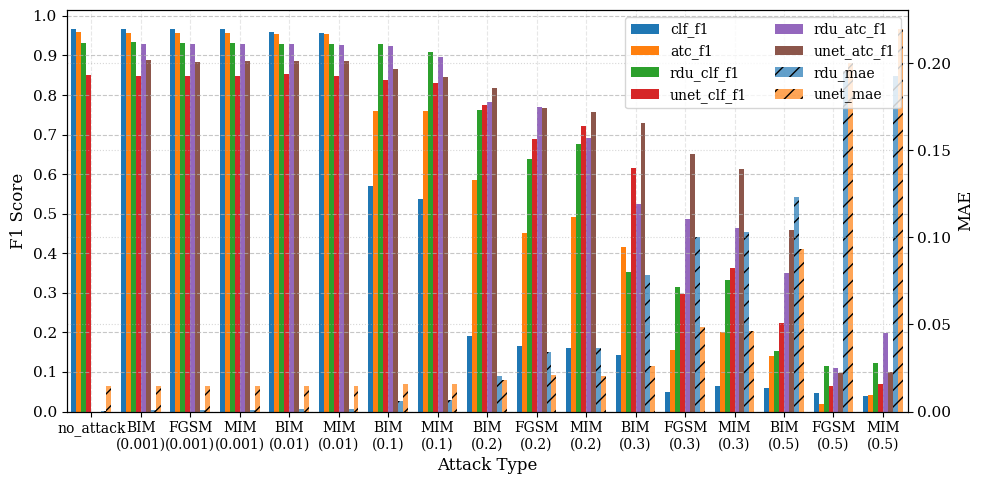

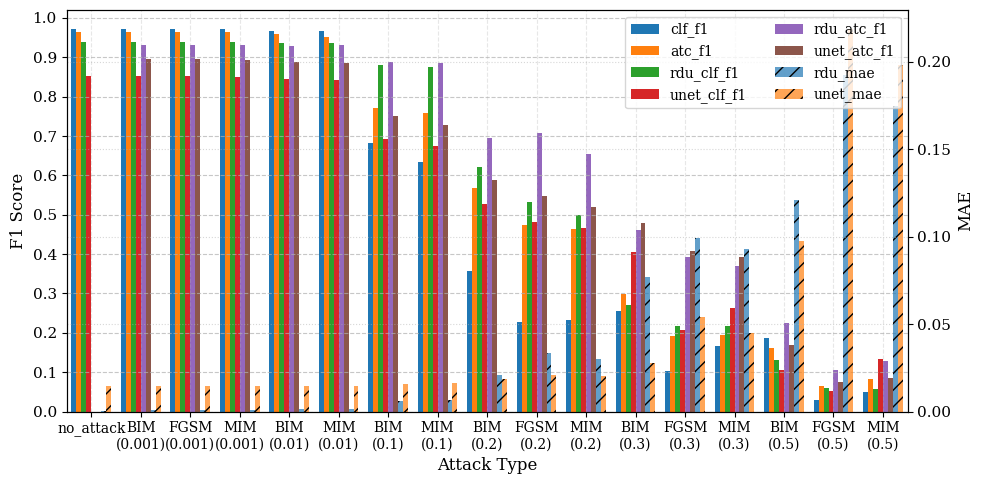

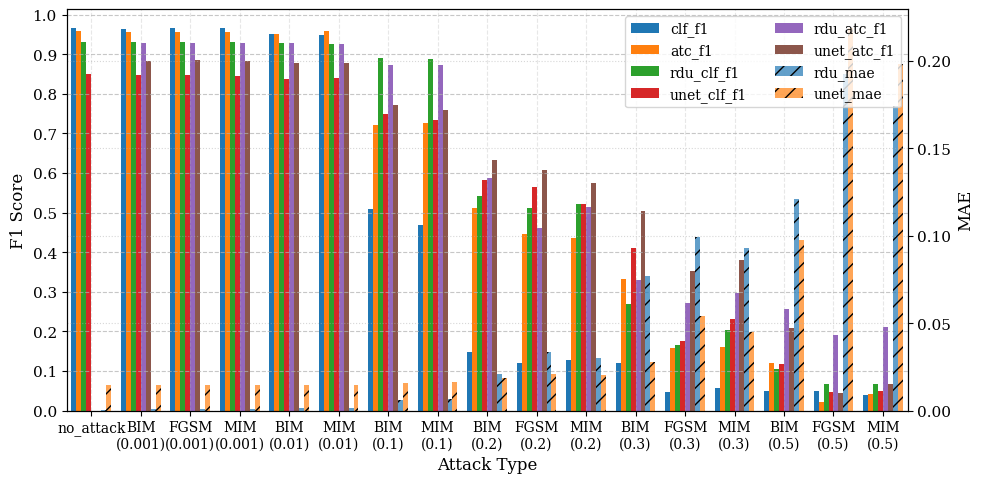

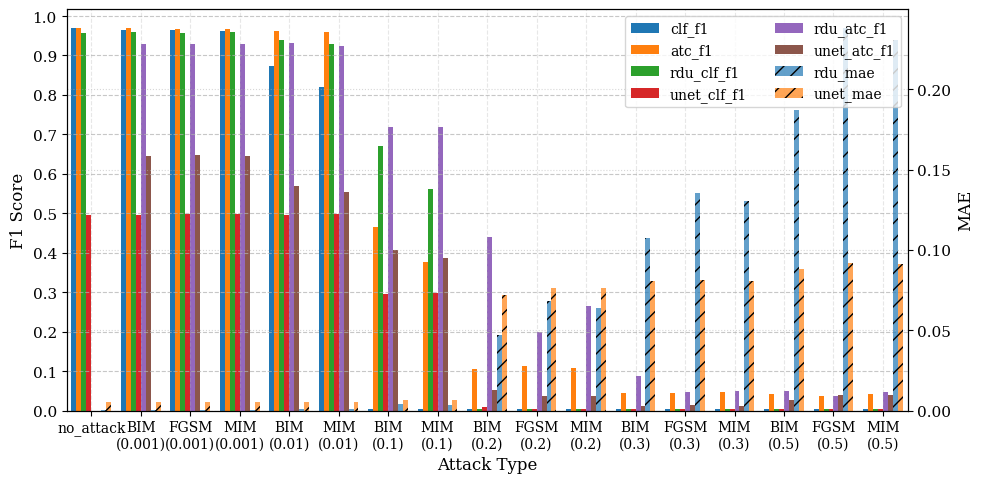

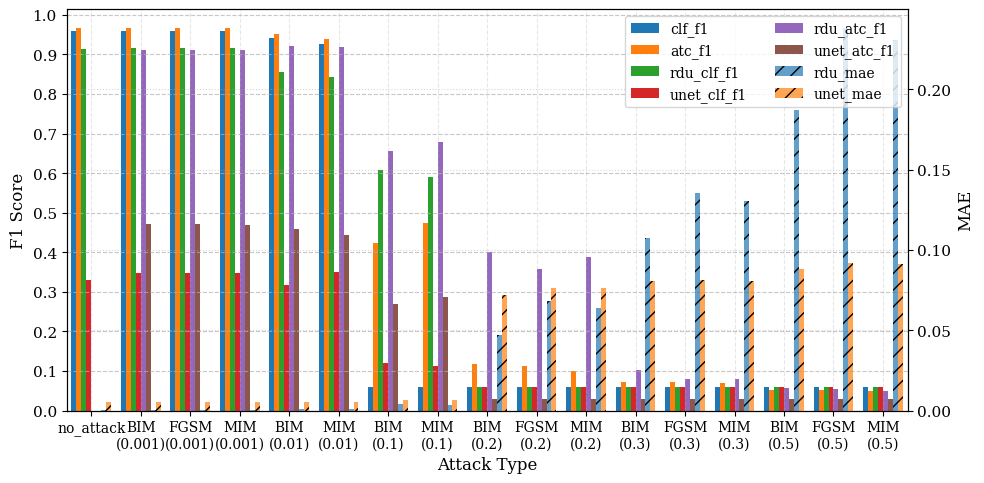

In [388]:

def generate_eval_plots(csv_files,curr_mode='train', show=True, ret_figs=True):
    fig_idx=0
    bars_df = {}
    figs = {}
    suffix=f'{curr_mode}_'
    for csv_file in csv_files:
        adversarial_generator = csv_file.parent.name
        df = pd.read_csv(csv_file)
        print(adversarial_generator)
        
        model_types = ['resnet', 'mobilenet']
        ae_models = ['unet','rdunet']
    
    
    
        for model_type in model_types:
            bars = dict()
            result_file_name = f"{suffix}{adversarial_generator}_{model_type}.pdf"
            result_name = f"{adversarial_generator}_{model_type}"
            ndf = df[df.clf_model.apply(lambda x: model_type in x.lower())]
            
            # first get no atk results
            clf_f1 = ndf.clean_clf_f1.iloc[0]
            atc_f1 = ndf.clean_atc_f1.iloc[0]
            rdu_clf_f1=ndf[ndf.ae_model.apply(lambda x: 'rdunet' in x)].recon_clean_clf_f1.iloc[0]
            unet_clf_f1=ndf[ndf.ae_model.apply(lambda x: 'rdunet' not in x)].recon_clean_clf_f1.iloc[0]    
            rdu_mae = ndf[ndf.ae_model.apply(lambda x: 'rdunet' in x)].clean_mae.iloc[0]
            unet_mae = ndf[ndf.ae_model.apply(lambda x: 'rdunet' not in x)].clean_mae.iloc[0]
            
            
            bars['no_attack'] = dict(clf_f1=clf_f1,
                                     atc_f1=atc_f1,
                                     rdu_clf_f1=rdu_clf_f1,
                                     unet_clf_f1=unet_clf_f1,
                                     rdu_mae=rdu_mae,
                                     unet_mae=unet_mae
                                    ) 
            
        
            for adversarial_name, nndf in ndf.groupby('adversarial_name'):
                eps = float(adversarial_name.split('eps_')[-1])
                adv_name = 'BIM' if 'basic' in adversarial_name else 'FGSM' if 'fast' in adversarial_name else 'MIM'
                adv_name = f'{adv_name}({eps})'
                data_split='test'
                if adv_name in ['FGSM(0.1)','FGSM(0.01)',
                               'BIGM(0.1)','BIGM(0.01)']:

                    data_split='train'

                if data_split!=curr_mode:
                    continue
            
                    
        
                # first read values from rdunet
                values = nndf[nndf.ae_model.apply(lambda x: 'rdunet' in x)][['adv_clf_f1', 'adv_atc_f1', 'recon_adv_clf_f1', 'recon_adv_atc_f1', 'adv_mae']].values[0]
                new_values = nndf[nndf.ae_model.apply(lambda x: 'rdunet' not in x)][['recon_adv_clf_f1', 'recon_adv_atc_f1', 'adv_mae']].values[0]
        
                clf_f1=values[0]
                atc_f1=values[1]
                rdu_clf_f1 = values[2]
                rdu_atc_f1 = values[3]
                rdu_mae = values[4]
                unet_clf_f1 = new_values[0]
                unet_atc_f1 = new_values[1]
                unet_mae = new_values[2]
                
        
                bars[adv_name] = dict(clf_f1=values[0],
                                    atc_f1=values[1],
                                    rdu_clf_f1 = values[2],
                                    rdu_atc_f1 = values[3],
                                    rdu_mae = values[4],
                                    unet_clf_f1 = new_values[0],
                                    unet_atc_f1 = new_values[1],
                                    unet_mae = new_values[2])
        
                
        
            print(fig_idx, result_file_name)
            
            bars_df[result_name], figs[result_name]=plot_bars(bars, 'eval_'+result_file_name, show) 
            
            fig_idx+=1
    if ret_figs:
        return bars_df, figs
    else:
        return bars_df, None

train_bars, train_figs = generate_eval_plots(csv_files,show=False, ret_figs=False)
test_bars, test_figs = generate_eval_plots(csv_files, curr_mode='test', show=False,ret_figs=False)
    



In [374]:
columns = ['clf_f1', 'atc_f1', 'rdu_clf_f1', 'unet_clf_f1', 
       'rdu_atc_f1', 'unet_atc_f1','rdu_mae', 'unet_mae']


for res_name, bar_df in train_bars.items():
    bar_df=bar_df[columns]
    bar_df.index = [x.replace('\n','') for x in bar_df.index]
    train_bars[bar_df] = bar_df
    


,clf_f1,atc_f1,rdu_clf_f1,unet_clf_f1,rdu_atc_f1,unet_atc_f1,rdu_mae,unet_mae
no_attack,0.969131,0.969407,0.958113,0.496420,NaN,NaN,0.000256,0.005482
BIM\n(0.01),0.934404,0.966536,0.950342,0.497632,0.941495,0.653991,0.000948,0.005557
FGSM\n(0.01),0.930550,0.966967,0.950862,0.494987,0.942020,0.635224,0.000947,0.005554
BIM\n(0.1),0.003856,0.640076,0.583773,0.239655,0.784303,0.414811,0.004027,0.006523
FGSM\n(0.1),0.003856,0.533690,0.647257,0.245243,0.776784,0.399497,0.003519,0.006698
